Full confusion matrix again:
```
                Actual: YES(1)     Actual: NO(0)
Predicted: YES    TP = 4             FP = 1
Predicted: NO     FN = 0             TN = 5
```
FPR only cares about the "Actual: NO" column (the right-hand column above) — the people who are truly negative. Out of those people, how many did the model wrongly flag as YES?

* Total actually-NO people = FP + TN = 1 + 5 = 6
* Of those 6, how many got wrongly predicted YES? That's just FP = 1

So:
```
FPR = FP / (FP + TN) = 1 / 6 ≈ 0.167
```
Compare that side-by-side with Recall (TPR), which you already nailed yesterday:
```
TPR (Recall) = TP / (TP + FN) = 4 / 4 = 1.00
```
Notice the pattern: TPR and FPR are structural mirrors of each other —
```
	              Uses actual-YES row	Uses actual-NO row
"Caught" fraction	TPR = TP/(TP+FN)	FPR = FP/(FP+TN)
```

Both TPR and FPR move in the same direction as threshold changes (both fall as threshold rises, both rise as threshold falls). That's not a coincidence — it's because both are driven by the same underlying lever: how many people land in "Predicted: YES."

At threshold = 1.0, the rule is: predict PASS only if predict_proba(student) >= 1.0. Since sigmoid never actually reaches 1.0 (remember Day 9 — it only approaches, never touches), literally nobody clears this bar. Every single student gets predicted FAIL(0), no matter what.

So walk through all 10 students from yesterday's dataset:
```
actual:      [0 0 0 0 0 0 1 1 1 1]
predicted:   [0 0 0 0 0 0 0 0 0 0]   <- everyone predicted FAIL now
```
Now fill in the grid by comparing predicted vs actual, one box at a time:
```
TP (predicted YES, actual YES) → nobody was predicted YES, so TP = 0
FP (predicted YES, actual NO) → nobody was predicted YES, so FP = 0
FN (predicted NO, actual YES) → all 4 real passers got predicted FAIL → FN = 4
TN (predicted NO, actual NO) → all 6 real failers got predicted FAIL (correctly) → TN = 6
```
Now plug into the formulas:
```
TPR = TP/(TP+FN) = 0/(0+4) = 0
FPR = FP/(FP+TN) = 0/(0+6) = 0
```
So at threshold=1.0, the ROC point is (FPR=0, TPR=0) — the bottom-left corner of the curve. Makes sense: predicting nobody as positive means zero false alarms, but also zero real catches.

At threshold = 0.0, the rule is: predict PASS if predict_proba(student) >= 0.0. Since every probability is always >= 0, everyone gets predicted PASS(1) — no exceptions.
```
actual:      [0 0 0 0 0 0 1 1 1 1]
predicted:   [1 1 1 1 1 1 1 1 1 1]   <- everyone predicted PASS now
```
Fill in the grid box by box:
```
TP (predicted YES, actual YES) → all 4 real passers correctly flagged → TP = 4
FP (predicted YES, actual NO) → all 6 real failers wrongly flagged → FP = 6
FN (predicted NO, actual YES) → nobody was predicted NO → FN = 0
TN (predicted NO, actual NO) → nobody was predicted NO → TN = 0
```
Plug in:
```
TPR = TP/(TP+FN) = 4/(4+0) = 1.0
FPR = FP/(FP+TN) = 6/(6+0) = 1.0
```
So the ROC point at threshold=0.0 is (FPR=1, TPR=1) — top-right corner.

Putting both extremes together:
```
Threshold	        Point (FPR, TPR)    Meaning
1.0 (impossibly strict)	(0, 0)	            bottom-left — predict nobody positive
0.0 (no filter at all)	(1, 1)	            top-right — predict everybody positive
```
Every real threshold in between (0.3, 0.5, 0.7, etc.) produces a point somewhere between these two corners. Connect all those points as threshold sweeps continuously from 1.0 down to 0.0, and you get the ROC curve — a path from (0,0) to (1,1).

In [9]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.loss_history = []

    def fit(self, X, y):
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])
        self.w = np.zeros(X_b.shape[1])
        for i in range(self.n_iterations):
            predictions = sigmoid(X_b @ self.w)
            gradient = X_b.T @ (predictions - y)
            self.w = self.w - self.learning_rate * gradient
            bce = -np.mean(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
            self.loss_history.append(bce)
        return self

    def predict_proba(self, X):
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])
        return sigmoid(X_b @ self.w)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

In [12]:
import numpy as np

# same 1-feature dataset from Day 9
hours = np.array([1, 2, 2.5, 3, 4, 5, 6, 7, 8, 9]).reshape(-1, 1)
y_actual = np.array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1])

model = LogisticRegressionScratch(learning_rate=0.01, n_iterations=1000)
model.fit(hours, y_actual)

# refit (or reuse) the 1-feature model from Day 9
probs = model.predict_proba(hours)   # X_hours = your original hours column
print(probs)

[0.00635423 0.01630234 0.02598557 0.04117964 0.10015445 0.2238691
 0.4277567  0.65953896 0.83389541 0.92862387]


In [13]:
threshold = 0.5
predicted = (probs >= threshold).astype(int)
print(predicted)
print(y_actual)

[0 0 0 0 0 0 0 1 1 1]
[0 0 0 0 0 0 0 1 1 1]


In [15]:
TP = 3
FP = 0
FN = 0
TN = 7

TPR = TP / (TP + FN)
FPR = FP / (FP + TN)
print(f"threshold={threshold}: TPR={TPR}, FPR={FPR}")

threshold=0.5: TPR=1.0, FPR=0.0


In [16]:
def compute_roc_point(y_actual, probs, threshold):
    predicted = (probs >= threshold).astype(int)

    TP = np.sum((predicted == 1) & (y_actual == 1))
    FP = np.sum((predicted == 1) & (y_actual == 0))
    FN = np.sum((predicted == 0) & (y_actual == 1))
    TN = np.sum((predicted == 0) & (y_actual == 0))

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)

    return FPR, TPR

In [17]:
fpr, tpr = compute_roc_point(y_actual, probs, threshold=0.5)
print(fpr, tpr)

0.0 1.0


In [18]:
thresholds = np.linspace(0, 1, 21)   # 21 points from 0.0 to 1.0
roc_points = [compute_roc_point(y_actual, probs, t) for t in thresholds]

for t, (fpr, tpr) in zip(thresholds, roc_points):
    print(f"threshold={t:.2f}  FPR={fpr:.3f}  TPR={tpr:.3f}")

threshold=0.00  FPR=1.000  TPR=1.000
threshold=0.05  FPR=0.429  TPR=1.000
threshold=0.10  FPR=0.429  TPR=1.000
threshold=0.15  FPR=0.286  TPR=1.000
threshold=0.20  FPR=0.286  TPR=1.000
threshold=0.25  FPR=0.143  TPR=1.000
threshold=0.30  FPR=0.143  TPR=1.000
threshold=0.35  FPR=0.143  TPR=1.000
threshold=0.40  FPR=0.143  TPR=1.000
threshold=0.45  FPR=0.000  TPR=1.000
threshold=0.50  FPR=0.000  TPR=1.000
threshold=0.55  FPR=0.000  TPR=1.000
threshold=0.60  FPR=0.000  TPR=1.000
threshold=0.65  FPR=0.000  TPR=1.000
threshold=0.70  FPR=0.000  TPR=0.667
threshold=0.75  FPR=0.000  TPR=0.667
threshold=0.80  FPR=0.000  TPR=0.667
threshold=0.85  FPR=0.000  TPR=0.333
threshold=0.90  FPR=0.000  TPR=0.333
threshold=0.95  FPR=0.000  TPR=0.000
threshold=1.00  FPR=0.000  TPR=0.000


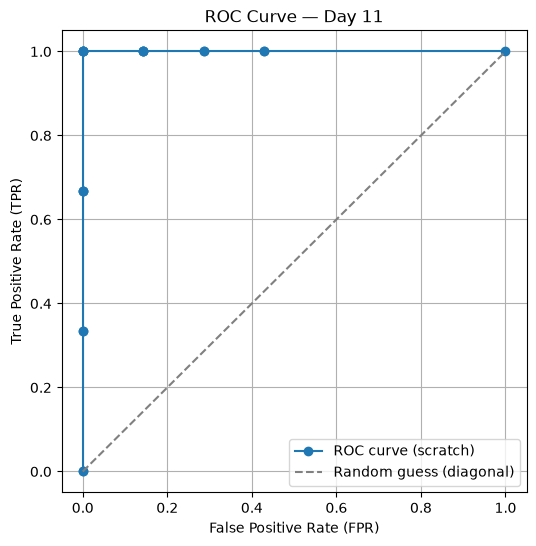

In [20]:
import matplotlib.pyplot as plt

fprs = [p[0] for p in roc_points]
tprs = [p[1] for p in roc_points]

plt.figure(figsize=(6,6))
plt.plot(fprs, tprs, marker='o', label='ROC curve (scratch)')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess (diagonal)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve — Day 11')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# sort by FPR ascending (needed for trapezoidal integration to work correctly)

order = np.argsort(fprs)
fprs_sorted = np.array(fprs)[order]
tprs_sorted = np.array(tprs)[order]

auc = np.trapezoid(tprs_sorted, fprs_sorted)
print(f"AUC = {auc:.4f}")

AUC = 0.9286


In [23]:
# Cheking it aginst the SKlearn

from sklearn.metrics import roc_curve, roc_auc_score

fpr_sk, tpr_sk, thresholds_sk = roc_curve(y_actual, probs)
auc_sk = roc_auc_score(y_actual, probs)

print("sklearn AUC:", auc_sk)

sklearn AUC: 1.0


In [24]:
print("sklearn FPR points:", fpr_sk)
print("sklearn TPR points:", tpr_sk)
print("sklearn thresholds:", thresholds_sk)
print("number of points:", len(fpr_sk))

sklearn FPR points: [0. 0. 0. 1.]
sklearn TPR points: [0.         0.33333333 1.         1.        ]
sklearn thresholds: [       inf 0.92862387 0.65953896 0.00635423]
number of points: 4


In [25]:
print("Our FPR (sorted):", fprs_sorted)
print("Our TPR (sorted):", tprs_sorted)

Our FPR (sorted): [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.14285714 0.14285714 0.14285714 0.14285714 0.28571429 0.28571429
 0.42857143 0.42857143 1.        ]
Our TPR (sorted): [1.         0.66666667 1.         0.66666667 1.         1.
 1.         0.66666667 0.         0.33333333 0.33333333 0.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.        ]


Confirmed exactly what we suspected — look at the very first stretch of tied FPR=0.000 points:
```
TPR: 1.0, 0.667, 1.0, 0.667, 1.0, 1.0, 1.0, 0.667, 0.0, 0.333, 0.333, 0.0
```
That's completely scrambled — it should be monotonically decreasing as threshold falls (matching your original printed sweep: 1.0 → 1.0 → ... → 0.667 → ... → 0.333 → ... → 0.0), but sorting by FPR alone shuffled the TPR values into a jumbled mess whenever FPR ties occurred. np.trapezoid then draws straight lines between these out-of-order points, zig-zagging up and down instead of tracing the real curve — which corrupts the area calculation. That's the entire bug.

**The fix:** when FPR values tie, we need a secondary sort key — sort by FPR first, and within each FPR tie, sort by threshold (or equivalently, keep TPR in its correct threshold-order). The cleanest fix is to sort by threshold directly (since threshold order is what guarantees TPR/FPR move monotonically), then just reverse it so FPR goes from 0→1:

In [26]:
# thresholds descending (1.0 -> 0.0) naturally gives FPR ascending, TPR non-decreasing
order = np.argsort(thresholds)[::-1]   # sort thresholds descending
fprs_sorted = np.array(fprs)[order]
tprs_sorted = np.array(tprs)[order]

print("FPR sorted (fixed):", fprs_sorted)
print("TPR sorted (fixed):", tprs_sorted)

auc_fixed = np.trapezoid(tprs_sorted, fprs_sorted)
print(f"AUC (fixed) = {auc_fixed:.4f}")

FPR sorted (fixed): [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.14285714 0.14285714 0.14285714 0.14285714 0.28571429 0.28571429
 0.42857143 0.42857143 1.        ]
TPR sorted (fixed): [0.         0.         0.33333333 0.33333333 0.66666667 0.66666667
 0.66666667 1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.        ]
AUC (fixed) = 1.0000


In [27]:
print(f"Scratch AUC (fixed):  {auc_fixed:.4f}")
print(f"sklearn AUC:           {auc_sk:.4f}")

Scratch AUC (fixed):  1.0000
sklearn AUC:           1.0000


**Quick recap of the whole mechanism before we move to interview questions:**

* TPR/FPR both live in the "predicted-YES row" but split by actual-YES vs actual-NO columns
* Sweeping threshold traces a path from (0,0) to (1,1), always moving monotonically
* AUC = area under that path, bounded between 0 (never happens with valid predictions) and 1
* This model achieved a genuinely perfect AUC=1.0 — it's fully separable at some threshold

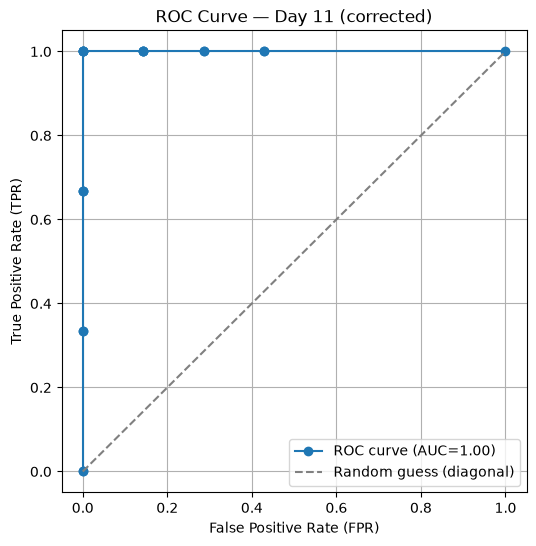

In [28]:
plt.figure(figsize=(6,6))
plt.plot(fprs_sorted, tprs_sorted, marker='o', label=f'ROC curve (AUC={auc_fixed:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess (diagonal)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve — Day 11 (corrected)')
plt.legend()
plt.grid(True)
plt.show()